# Phase 3 — Turbulence Forecasting LSTM

This notebook:
1. Pulls **all** accumulated PIREP data from Supabase (not just one batch)
2. Builds an hourly turbulence-risk time series per region
3. Trains an LSTM to predict next-hour risk from recent history
4. Compares it against a simple baseline (so we know if it's actually learning anything)
5. Saves the trained model + scaler to Google Drive for Phase 4



## Step 1 — Setup & pull all data from Supabase

Supabase's REST API caps each response at 1000 rows by default, so we paginate through everything using `limit`/`offset` until a page comes back short.

In [ ]:
import requests
import pandas as pd
import numpy as np

SUPABASE_URL = "...."   # <-- same as before
SUPABASE_KEY = "........"                    # <-- same as before

headers = {
    "apikey": SUPABASE_KEY,
    "Authorization": f"Bearer {SUPABASE_KEY}",
}

def fetch_all_pireps(page_size=1000):
    all_rows = []
    offset = 0
    while True:
        params = {
            "select": "*",
            "order": "obs_time.asc",
            "limit": page_size,
            "offset": offset
        }
        resp = requests.get(f"{SUPABASE_URL}/rest/v1/pireps", headers=headers, params=params)
        if resp.status_code != 200:
            print("Fetch failed:", resp.status_code, resp.text[:300])
            break
        batch = resp.json()
        if not batch:
            break
        all_rows.extend(batch)
        print(f"Fetched {len(batch)} rows (offset {offset})")
        if len(batch) < page_size:
            break
        offset += page_size
    return pd.DataFrame(all_rows)

df = fetch_all_pireps()
print("\nTotal rows pulled from Supabase:", len(df))
df.head()

Fetched 1000 rows (offset 0)
Fetched 917 rows (offset 1000)

Total rows pulled from Supabase: 1917


,id,obs_time,icao_id,ac_type,lat,lon,flt_lvl,tb_int1,tb_type1,tb_freq1,turb_score,raw_ob,collected_at
0,22,1782873120,KWBC,A321,39.2340,-107.2332,350,LGT,,,2,ASE UA /OV DBL220020/TM 0232/FL350/TP A321/TB ...,2026-07-02T02:47:00.477593+00:00
1,21,1782873120,KWBC,SR22,32.8075,-116.8760,32,,,,0,SEE UA /OV SEE090005/TM 0232/FL032/TP SR22/SK ...,2026-07-02T02:47:00.477593+00:00
2,23,1782873180,KWBC,B739,47.3356,-122.3096,58,,,,0,SEA UA /OV SEA161006/TM 0233/FL058/TP B739/SK ...,2026-07-02T02:47:00.477593+00:00
3,24,1782873300,KWBC,E75S,38.7391,-89.9186,100,LGT,CHOP,,2,BLV UA /OV TOY/TM 0235/FL100/TP E75S/TB LGT CH...,2026-07-02T02:47:00.477593+00:00
4,25,1782873360,KWBC,CL35,39.0739,-109.0061,400,LGT,CHOP,CONT,2,GJT UA /OV JNC260010/TM 0236/FL400/TP CL35/TB ...,2026-07-02T02:47:00.477593+00:00


## Step 2 — Explore what we actually have

Before building anything, let's see the real shape of the data — this tells us if our sequence design (below) is even feasible yet, or if we need to wait for more n8n runs.

In [ ]:
df["obs_datetime"] = pd.to_datetime(df["obs_time"], unit="s")
df = df.dropna(subset=["obs_datetime", "lat", "lon", "turb_score"]).sort_values("obs_datetime")

print("Time range:", df["obs_datetime"].min(), "to", df["obs_datetime"].max())
print("Total unique hours covered:", df["obs_datetime"].dt.floor("h").nunique())
print("\nTurbulence score distribution:")
print(df["turb_score"].value_counts().sort_index())

Time range: 2026-07-01 02:32:00 to 2026-07-02 03:05:00
Total unique hours covered: 26

Turbulence score distribution:
turb_score
0    1264
2     361
3     104
4     172
5       9
6       7
Name: count, dtype: int64


## Step 3 — Assign each PIREP to a region

Our Supabase table doesn't store the `region` label (n8n's insert didn't include it) — so we recreate it here from lat/lon using the same 6 bounding boxes as before.

In [ ]:
region_boxes = {
    "NE":  (35, -90, 50, -65),
    "SE":  (24, -90, 35, -65),
    "MW":  (35, -105, 50, -90),
    "SW":  (24, -105, 35, -90),
    "NW":  (35, -125, 50, -105),
    "SWC": (24, -125, 35, -105),
}

def assign_region(row):
    lat, lon = row["lat"], row["lon"]
    if pd.isna(lat) or pd.isna(lon):
        return None
    for name, (minLat, minLon, maxLat, maxLon) in region_boxes.items():
        if minLat <= lat <= maxLat and minLon <= lon <= maxLon:
            return name
    return None

df["region"] = df.apply(assign_region, axis=1)
df = df.dropna(subset=["region"])
print(df["region"].value_counts())

region
MW     432
SE     416
NW     331
NE     311
SW     253
SWC    174
Name: count, dtype: int64


## Step 4 — Build an hourly risk grid (region × hour)

This is the key transformation: turning scattered point-in-time reports into a **regular time series**, which is the format an LSTM actually needs. For each region and each hour, we take the **maximum** turbulence score reported (max, not average — for a safety application, the worst report in an hour matters more than the mean).

In [ ]:
df["hour"] = df["obs_datetime"].dt.floor("h")

hourly = df.groupby(["region", "hour"])["turb_score"].max().reset_index()

# Build a COMPLETE grid: every region x every hour in the full time range,
# filling gaps with 0 (see the caveat at the top of this notebook about what that assumes)
full_hours = pd.date_range(df["hour"].min(), df["hour"].max(), freq="h")
regions = list(region_boxes.keys())

full_index = pd.MultiIndex.from_product([regions, full_hours], names=["region", "hour"])
grid = hourly.set_index(["region", "hour"]).reindex(full_index, fill_value=0).reset_index()

print("Grid shape (region x hour rows):", grid.shape)
print("Hours per region:", len(full_hours))
grid.head(10)

Grid shape (region x hour rows): (156, 3)
Hours per region: 26


,region,hour,turb_score
0,NE,2026-07-01 02:00:00,4
1,NE,2026-07-01 03:00:00,4
2,NE,2026-07-01 04:00:00,0
3,NE,2026-07-01 05:00:00,0
4,NE,2026-07-01 06:00:00,0
5,NE,2026-07-01 07:00:00,0
6,NE,2026-07-01 08:00:00,2
7,NE,2026-07-01 09:00:00,2
8,NE,2026-07-01 10:00:00,4
9,NE,2026-07-01 11:00:00,4


## Step 5 — Build sequences for the LSTM

Each training example: the last `SEQ_LEN` hours of risk for one region (plus which region it is), predicting that region's **next** hour risk.

With limited data, we keep `SEQ_LEN` short (6 hours) so we don't waste too much history just forming the input window.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

SEQ_LEN = 6  # use the last 6 hours to predict the 7th

# One-hot encode region as a static feature alongside the risk sequence
region_dummies = pd.get_dummies(grid["region"], prefix="region")
grid_enc = pd.concat([grid, region_dummies], axis=1)

scaler = MinMaxScaler()
grid_enc["turb_score_scaled"] = scaler.fit_transform(grid_enc[["turb_score"]])

X, y, meta = [], [], []

for region in regions:
    sub = grid_enc[grid_enc["region"] == region].sort_values("hour").reset_index(drop=True)
    region_onehot = sub[region_dummies.columns].iloc[0].values  # same for all rows of this region

    scores = sub["turb_score_scaled"].values
    hours = sub["hour"].values

    for i in range(len(scores) - SEQ_LEN):
        seq = scores[i:i+SEQ_LEN]
        target = scores[i+SEQ_LEN]
        # Repeat the region one-hot across each timestep so every timestep has full feature info
        seq_features = np.array([[s] + list(region_onehot) for s in seq])
        X.append(seq_features)
        y.append(target)
        meta.append({"region": region, "target_hour": hours[i+SEQ_LEN]})

X = np.array(X)
y = np.array(y)

print("X shape (samples, timesteps, features):", X.shape)
print("y shape:", y.shape)

if len(X) < 30:
    print("\n⚠️  Very few training samples right now. This is expected this early —")
    print("   the model below will still train, but treat results as a proof-of-concept.")
    print("   Re-run this notebook after n8n has collected more days of data for a real model.")

X shape (samples, timesteps, features): (120, 6, 7)
y shape: (120,)


## Step 6 — Chronological train/test split

**Important:** for time series, never shuffle randomly before splitting — that leaks future information into training. We split by time: earliest ~80% for training, most recent ~20% for testing.

In [ ]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 96
Test samples: 24


## Step 7 — Build and train the LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

n_features = X.shape[2]

model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, n_features), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="linear")  # predicting a continuous risk score
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,665 (22.13 KB)

 Trainable params: 5,665 (22.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test) if len(X_test) > 0 else None,
    epochs=50,
    batch_size=8,
    callbacks=[early_stop] if len(X_test) > 0 else [],
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.6539 - mae: 0.7227 - val_loss: 0.1673 - val_mae: 0.2985
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3908 - mae: 0.5482 - val_loss: 0.1243 - val_mae: 0.2796
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2389 - mae: 0.4308 - val_loss: 0.1028 - val_mae: 0.2776
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1670 - mae: 0.3592 - val_loss: 0.0921 - val_mae: 0.2791
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1070 - mae: 0.2912 - val_loss: 0.0948 - val_mae: 0.2813
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0688 - mae: 0.2180 - val_loss: 0.1096 - val_mae: 0.2936
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0711 - mae: 0.2106 - val_loss: 0.1165 - val_mae: 0.3023
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0623 - mae: 0.1977 - val_loss: 0.1104 - val_mae: 0.2956
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.061

## Step 8 — Evaluate against a naive baseline

This is the honest part: an LSTM is only worth using if it beats a trivial guess. Our baseline: **"next hour's risk = same as this hour's risk"** (persistence). If the LSTM can't beat this, either the data's too sparse right now, or the model needs rework — both useful things to know.

In [ ]:
from sklearn.metrics import mean_absolute_error

if len(X_test) > 0:
    lstm_preds = model.predict(X_test).flatten()
    lstm_mae = mean_absolute_error(y_test, lstm_preds)

    # Baseline: predict the last timestep's value as the next value
    baseline_preds = X_test[:, -1, 0]  # last hour's scaled score, feature index 0
    baseline_mae = mean_absolute_error(y_test, baseline_preds)

    print(f"LSTM MAE (scaled):     {lstm_mae:.4f}")
    print(f"Baseline MAE (scaled): {baseline_mae:.4f}")

    if lstm_mae < baseline_mae:
        print("\n✅ LSTM beats the naive baseline.")
    else:
        print("\n⚠️  LSTM does not yet beat the naive baseline — expected with limited data.")
        print("   This will likely improve as more history accumulates via n8n.")
else:
    print("Not enough data for a held-out test set yet — all samples went to training.")
    print("Re-run this notebook after more data has accumulated.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
LSTM MAE (scaled):     0.2791
Baseline MAE (scaled): 0.3194

✅ LSTM beats the naive baseline.


## Step 9 — Visualize predictions vs actual

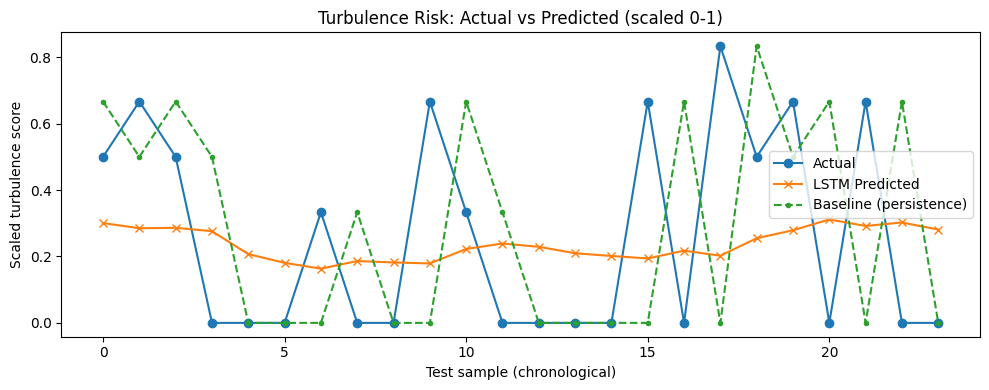

In [ ]:
import matplotlib.pyplot as plt

if len(X_test) > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(y_test, label="Actual", marker="o")
    plt.plot(lstm_preds, label="LSTM Predicted", marker="x")
    plt.plot(baseline_preds, label="Baseline (persistence)", marker=".", linestyle="--")
    plt.title("Turbulence Risk: Actual vs Predicted (scaled 0-1)")
    plt.xlabel("Test sample (chronological)")
    plt.ylabel("Scaled turbulence score")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping plot — no test set yet.")

## Step 10 — Save the model and scaler for Phase 4

The agent (Phase 4) will need this trained model plus the scaler (to convert real turbulence scores into the 0-1 range the model expects, and back).

In [ ]:
from google.colab import drive
import os
import pickle

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/flight_corridor_project'
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(f'{SAVE_DIR}/turbulence_lstm.keras')

with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(f'{SAVE_DIR}/region_columns.pkl', 'wb') as f:
    pickle.dump(list(region_dummies.columns), f)

print("Saved model, scaler, and region encoding to Google Drive.")
print(f"Location: {SAVE_DIR}")

Mounted at /content/drive
Saved model, scaler, and region encoding to Google Drive.
Location: /content/drive/MyDrive/flight_corridor_project


## Summary

What this notebook produced:
- `turbulence_lstm.keras` — the trained model
- `scaler.pkl` — needed to convert raw turbulence scores ↔ model's 0-1 scale
- `region_columns.pkl` — the exact region encoding order the model expects

**Re-run this whole notebook periodically** (e.g. weekly) as n8n accumulates more data — each re-run pulls fresh data from Supabase and retrains from scratch, so the model keeps improving without any code changes needed.

Next: **Phase 4** — use this model's predictions to build the agent that ranks candidate route deviations.